# Case study: workplace safety incidents

This case study fits a Poisson GLMM on a synthetic workplace-safety dataset to answer a
concrete question:

> *Does a new safety training programme reduce the rate of workplace incidents?*

**Dataset.** Twenty manufacturing plants are observed over eight consecutive months.
Ten plants received a safety training intervention at the start of the observation
period; the remaining ten serve as untreated controls. Each plant-month record
contains the number of reportable safety incidents and the number of employees
(exposure).

**Why this dataset?** Count data with an exposure offset is one of the most common
settings for a Poisson GLMM. The design is fully crossed (every plant observed in
every month), so it exercises interlace's crossed random-effects machinery. The dataset
is small enough to inspect by hand, and the data-generating process is transparent —
readers can compare the recovered estimates to the true parameters.

In [1]:
import numpy as np
import pandas as pd
import interlace
from plotnine import (
    ggplot, aes,
    geom_boxplot, geom_jitter, geom_point, geom_line, geom_col,
    geom_histogram, geom_hline, geom_abline, geom_bar,
    facet_wrap, labs, theme_bw, theme, element_text,
    scale_color_manual, scale_fill_manual, coord_flip,
    position_dodge, stat_qq, stat_qq_line,
)

# ---- Synthetic data generation ----
# True parameters (readers can compare recovered estimates to these)
TRUE_INTERCEPT = np.log(0.03)   # baseline rate: ~3 incidents per 100 employees per month
TRUE_TRAINING  = -0.45          # training reduces rate by ~36%  (exp(-0.45) ≈ 0.64)
TRUE_SD_PLANT  = 0.40           # between-plant SD on the log-rate scale
TRUE_SD_MONTH  = 0.20           # between-month SD on the log-rate scale

rng = np.random.default_rng(33)

n_plants = 20
n_months = 8
plants = [f"P{i+1:02d}" for i in range(n_plants)]
months = list(range(1, n_months + 1))

# Treatment assignment: first 10 plants received training
treatment = {p: 1 for p in plants[:10]}
treatment.update({p: 0 for p in plants[10:]})

# Plant size (employees) — varies from ~80 to ~280
plant_size = {p: int(rng.integers(80, 280)) for p in plants}

# Random effects (drawn once, fixed for the dataset)
u_plant = {p: rng.normal(0, TRUE_SD_PLANT) for p in plants}
u_month = {m: rng.normal(0, TRUE_SD_MONTH) for m in months}

rows = []
for p in plants:
    for m in months:
        log_rate = TRUE_INTERCEPT + TRUE_TRAINING * treatment[p] + u_plant[p] + u_month[m]
        expected = np.exp(log_rate) * plant_size[p]
        count = rng.poisson(expected)
        rows.append({
            "plant": p,
            "month": m,
            "training": treatment[p],
            "employees": plant_size[p],
            "incidents": count,
        })

df = pd.DataFrame(rows)
df["log_employees"] = np.log(df["employees"])
df["rate"] = df["incidents"] / df["employees"] * 100  # per 100 employees

print(f"Observations : {len(df)}")
print(f"Plants       : {df['plant'].nunique()} ({df.query('training==1')['plant'].nunique()} training, "
      f"{df.query('training==0')['plant'].nunique()} control)")
print(f"Months       : {df['month'].nunique()}")
print(f"Incident range: {df['incidents'].min()} – {df['incidents'].max()}")

Observations : 160
Plants       : 20 (10 training, 10 control)
Months       : 8
Incident range: 0 – 29


## Dataset

| Column | Description |
|---|---|
| `plant` | Plant ID (P01–P20) |
| `month` | Calendar month (1–8) |
| `training` | 1 if the plant received safety training, 0 otherwise |
| `employees` | Number of employees at the plant (exposure) |
| `incidents` | Count of reportable safety incidents that month |
| `rate` | Crude incident rate per 100 employees |

In [2]:
df.head(12)

,plant,month,training,employees,incidents,log_employees,rate
0,P01,1,1,255,6,5.541264,2.352941
1,P01,2,1,255,4,5.541264,1.568627
2,P01,3,1,255,1,5.541264,0.392157
3,P01,4,1,255,3,5.541264,1.176471
4,P01,5,1,255,2,5.541264,0.784314
5,P01,6,1,255,9,5.541264,3.529412
6,P01,7,1,255,3,5.541264,1.176471
7,P01,8,1,255,1,5.541264,0.392157
8,P02,1,1,168,2,5.123964,1.190476
9,P02,2,1,168,2,5.123964,1.190476


## The crossed structure

Every plant is observed in every month — the design is fully crossed. The table below
shows the incident count for each plant × month cell.

In [3]:
crossing = df.pivot_table(
    index="plant", columns="month",
    values="incidents", aggfunc="sum",
)
crossing.columns.name = "month"
crossing

month,1,2,3,4,5,6,7,8
plant,,,,,,,,
P01,6,4,1,3,2,9,3,1
P02,2,2,3,6,0,3,4,2
P03,4,6,4,5,7,7,5,3
P04,2,2,2,2,3,5,3,1
P05,6,8,2,8,2,8,6,5
P06,5,4,3,4,3,7,4,5
P07,1,1,2,4,2,0,1,4
P08,5,1,3,2,3,6,7,1
P09,4,8,3,3,4,4,8,4


## Exploratory analysis

### Distribution of incident counts

Safety incidents are counts — non-negative integers, often right-skewed.
The histogram below confirms this is count data with a mode near the low end,
suggesting a Poisson (or negative binomial) model rather than a linear model.

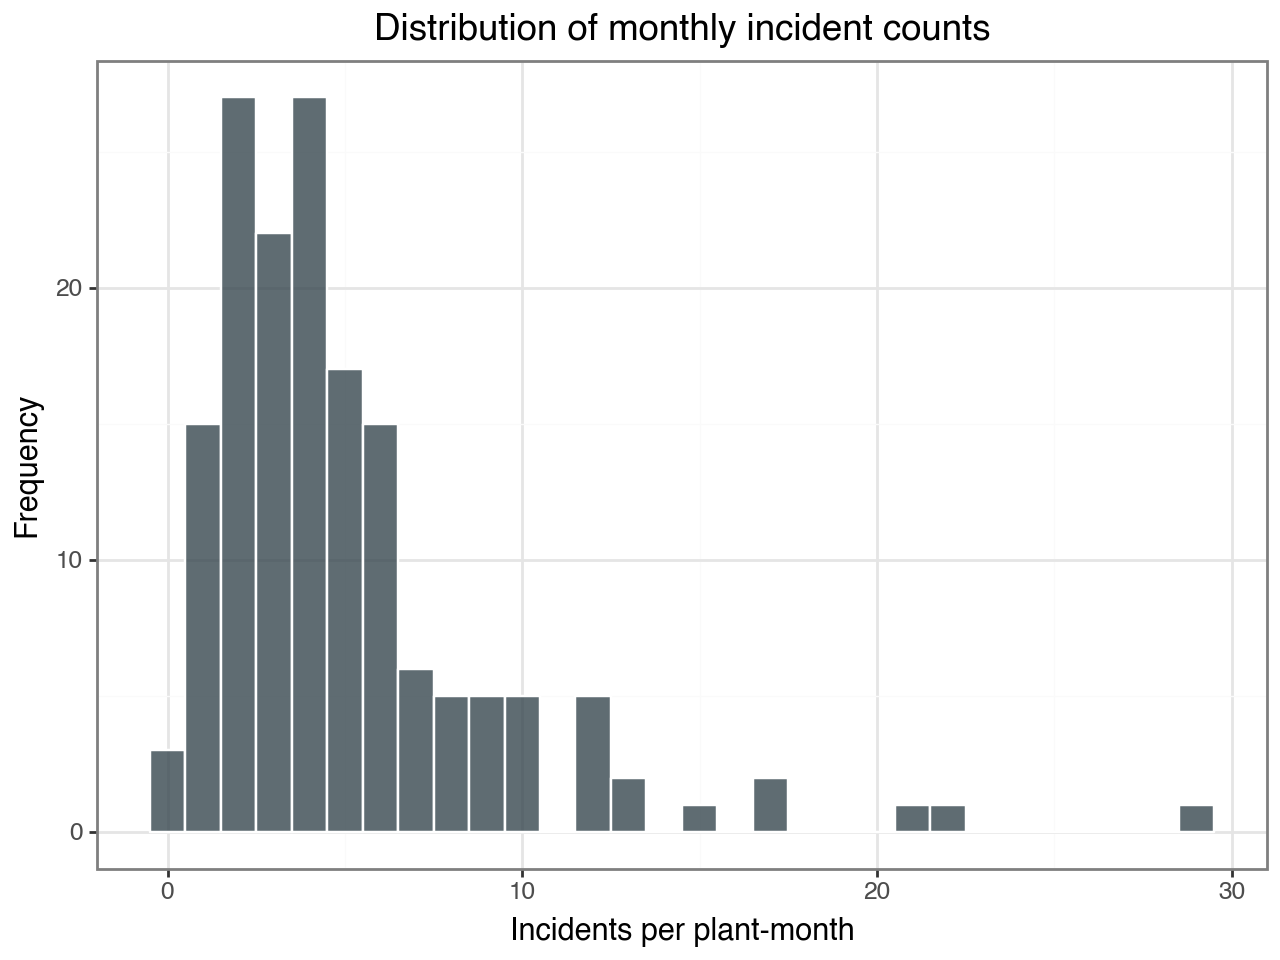

In [4]:
(
    ggplot(df, aes(x="incidents"))
    + geom_histogram(binwidth=1, fill="#37474F", color="white", alpha=0.8)
    + labs(
        x="Incidents per plant-month",
        y="Frequency",
        title="Distribution of monthly incident counts",
    )
    + theme_bw()
)

### Incident rates by treatment group

Comparing crude rates (incidents per 100 employees) between training and control
plants gives a first look at the treatment effect. The offset in the GLMM will
handle the exposure adjustment formally.

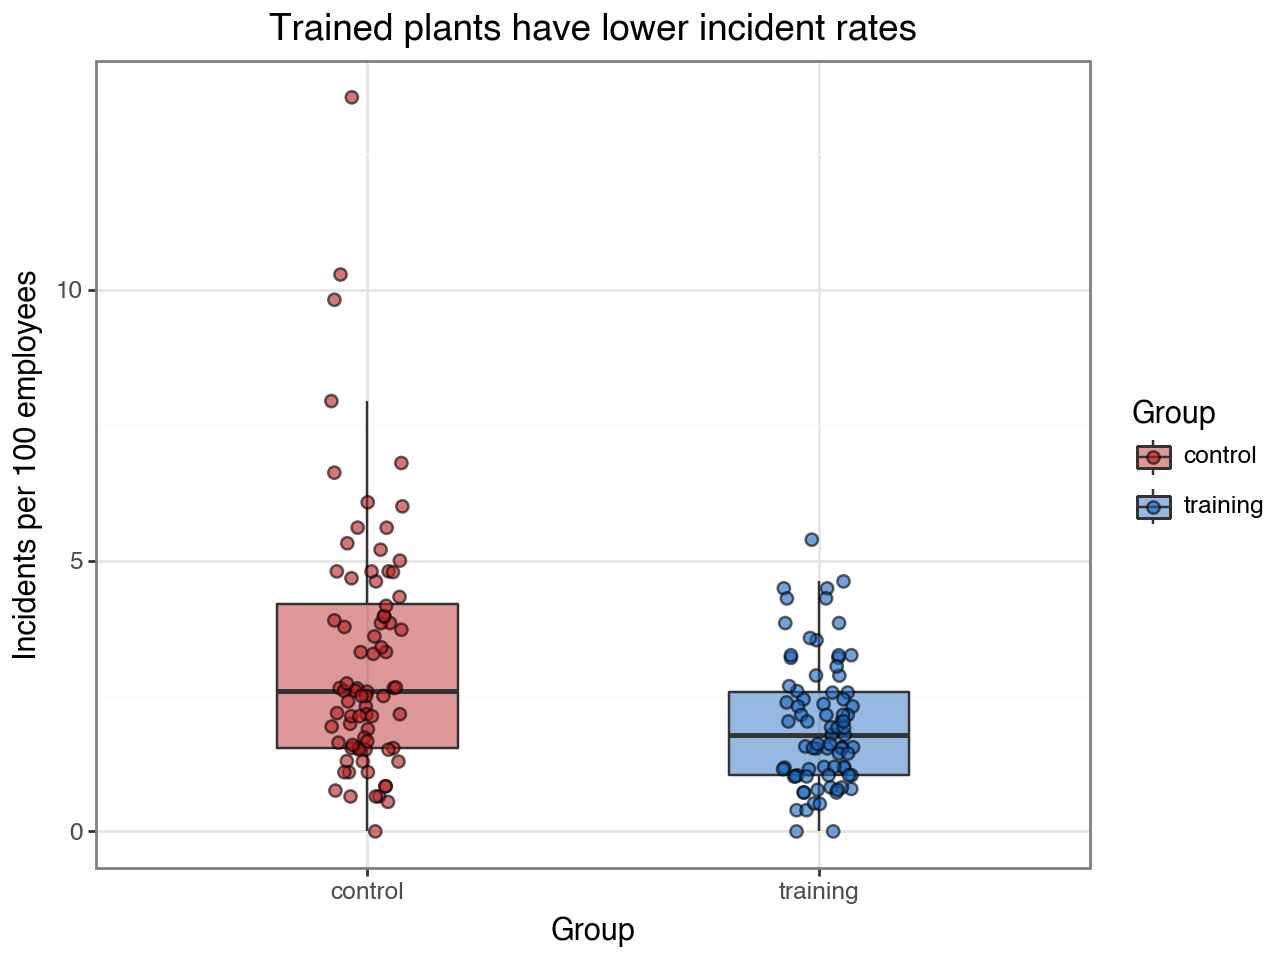

In [5]:
df["group"] = df["training"].map({1: "training", 0: "control"})

(
    ggplot(df, aes(x="group", y="rate", fill="group"))
    + geom_boxplot(alpha=0.45, outlier_shape=None, width=0.4)
    + geom_jitter(width=0.08, alpha=0.6, size=2)
    + scale_fill_manual(values={"training": "#1565C0", "control": "#B71C1C"})
    + labs(
        x="Group",
        y="Incidents per 100 employees",
        title="Trained plants have lower incident rates",
        fill="Group",
    )
    + theme_bw()
)

### Within-plant trends over time

Each line traces one plant's incident rate across the eight months. Training plants
(blue) tend to sit below control plants (red), and there is visible plant-to-plant
variation within each group — exactly the variation the plant random intercept will
absorb.

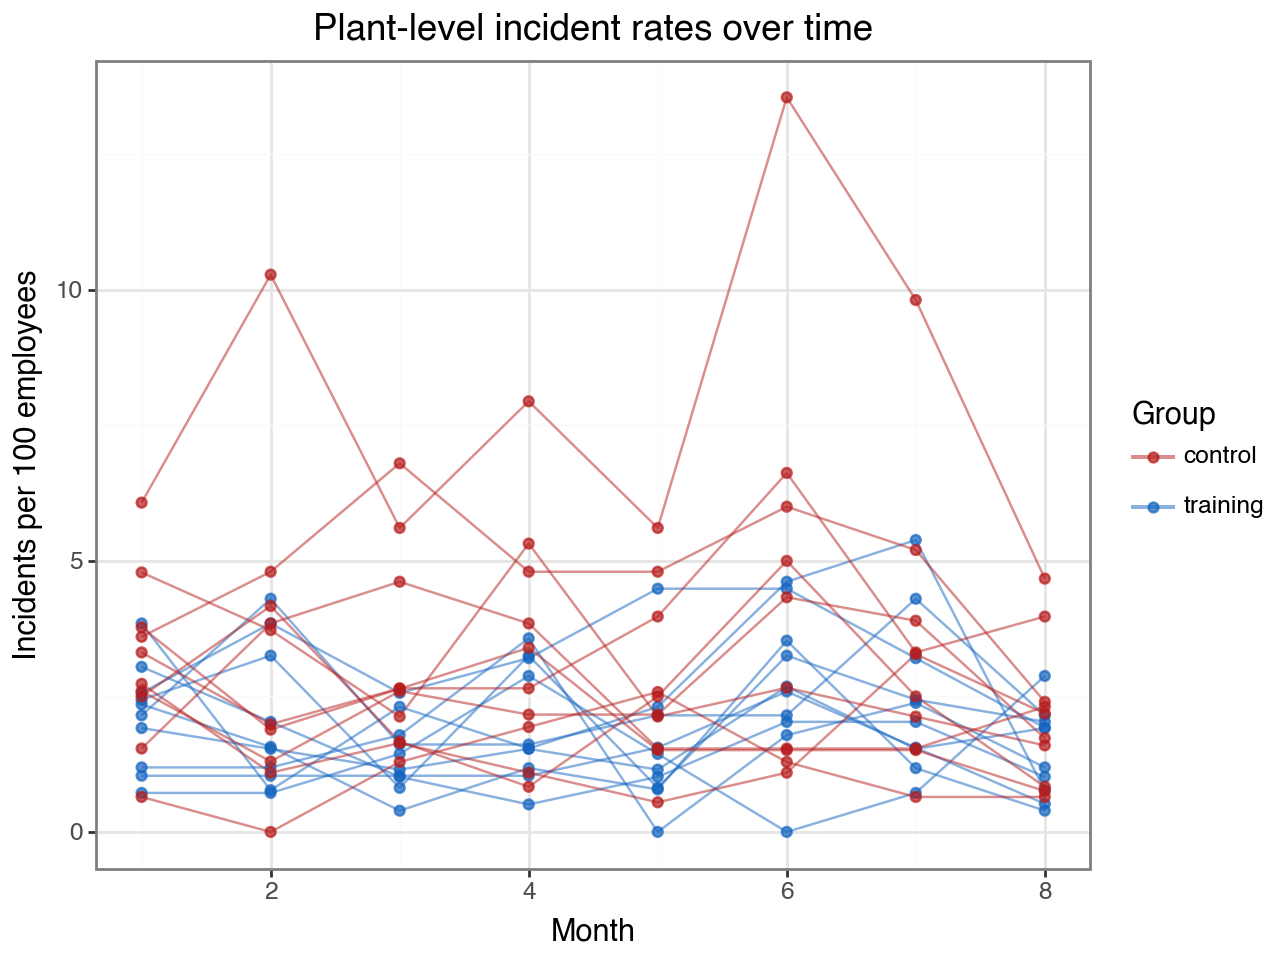

In [6]:
(
    ggplot(df, aes(x="month", y="rate", group="plant", color="group"))
    + geom_line(alpha=0.5)
    + geom_point(size=1.5, alpha=0.7)
    + scale_color_manual(values={"training": "#1565C0", "control": "#B71C1C"})
    + labs(
        x="Month",
        y="Incidents per 100 employees",
        title="Plant-level incident rates over time",
        color="Group",
    )
    + theme_bw()
)

## Model specification

```python
interlace.glmer(
    formula="incidents ~ training",
    data=df,
    family="poisson",
    groups=["plant", "month"],
    offset=np.log(df["employees"].values),
)
```

- **Outcome**: `incidents` — non-negative integer counts.
- **Family**: Poisson with a log link. The model assumes
  $\text{incidents}_i \sim \text{Poisson}(\mu_i)$ where
  $\log(\mu_i) = \mathbf{x}_i'\boldsymbol{\beta} + \mathbf{z}_i'\mathbf{u} + \log(\text{employees}_i)$.
- **Offset**: `log(employees)` converts the model from counts to rates. The fixed
  effects estimate the log *rate* (incidents per employee per month), not the log count.
- **Fixed effect**: `training` (1 = trained, 0 = control). The coefficient is a
  log rate ratio — exponentiate it to get the multiplicative effect on the incident rate.
- **Random intercept for `plant`**: plants differ in baseline safety culture,
  equipment age, workforce experience, etc.
- **Random intercept for `month`**: some months may have systematically higher or
  lower incident rates (seasonal patterns, holidays, reporting cycles).

The two random effects are **crossed** because every plant is observed in every month.

In [7]:
result = interlace.glmer(
    formula="incidents ~ training",
    data=df,
    family="poisson",
    groups=["plant", "month"],
    offset=np.log(df["employees"].values),
)

print(f"Converged    : {result.converged}")
print(f"Observations : {result.nobs}")
print(f"Groups       : {result.ngroups}")
print(f"AIC / BIC    : {result.aic:.1f} / {result.bic:.1f}")

Converged    : True
Observations : 160
Groups       : {'plant': 20, 'month': 8}
AIC / BIC    : 715.5 / 727.8


## Fixed effects

The coefficients are on the **log-rate scale** (log link). To interpret them
as multiplicative effects on the incident rate, exponentiate.

In [8]:
import scipy.stats

fe = pd.DataFrame({
    "estimate": result.fe_params,
    "se": result.fe_bse,
    "rate_ratio": np.exp(result.fe_params),
    "z": result.fe_params / result.fe_bse,
})
fe["p"] = 2 * scipy.stats.norm.sf(np.abs(fe["z"]))
fe.round(4)

,estimate,se,rate_ratio,z,p
Intercept,-3.5552,0.1509,0.0286,-23.5664,0.0000
training,-0.4170,0.1949,0.6590,-2.1399,0.0324


**Interpreting the training coefficient:**

- The estimate on the log scale should be near the true value of −0.45.
- The rate ratio (≈ 0.64) means trained plants experience roughly 36% fewer
  incidents per employee-month than control plants, after adjusting for
  plant-to-plant and month-to-month variation.
- The intercept (≈ −3.5) is the log baseline rate for control plants at an
  average month: exp(−3.5) ≈ 0.03 incidents per employee per month, or about
  3 per 100 employees — matching the true data-generating parameter.

## Variance components

How much variation in incident rates comes from plant identity versus temporal
fluctuation?

In [9]:
print(f"{'Source':<10}  {'Variance':>10}  {'SD':>8}  {'True SD':>10}")
print("-" * 46)
true_sds = {"plant": TRUE_SD_PLANT, "month": TRUE_SD_MONTH}
for g, v in result.variance_components.items():
    sd = v ** 0.5
    print(f"{g:<10}  {v:>10.4f}  {sd:>8.4f}  {true_sds[g]:>10.4f}")

Source        Variance        SD     True SD
----------------------------------------------
plant           0.1588    0.3984      0.4000
month           0.0338    0.1837      0.2000


The recovered standard deviations should be close to the true values (0.40 for
plant, 0.20 for month). Plants vary more than months, which makes sense — structural
differences between facilities (equipment, culture, workforce) create more variation
than month-to-month fluctuation within a single plant.

## Plant random effects (BLUPs)

The BLUPs estimate each plant's baseline safety level relative to the population
mean, on the log-rate scale. Positive values indicate higher-than-average incident
rates; negative values indicate safer-than-average plants.

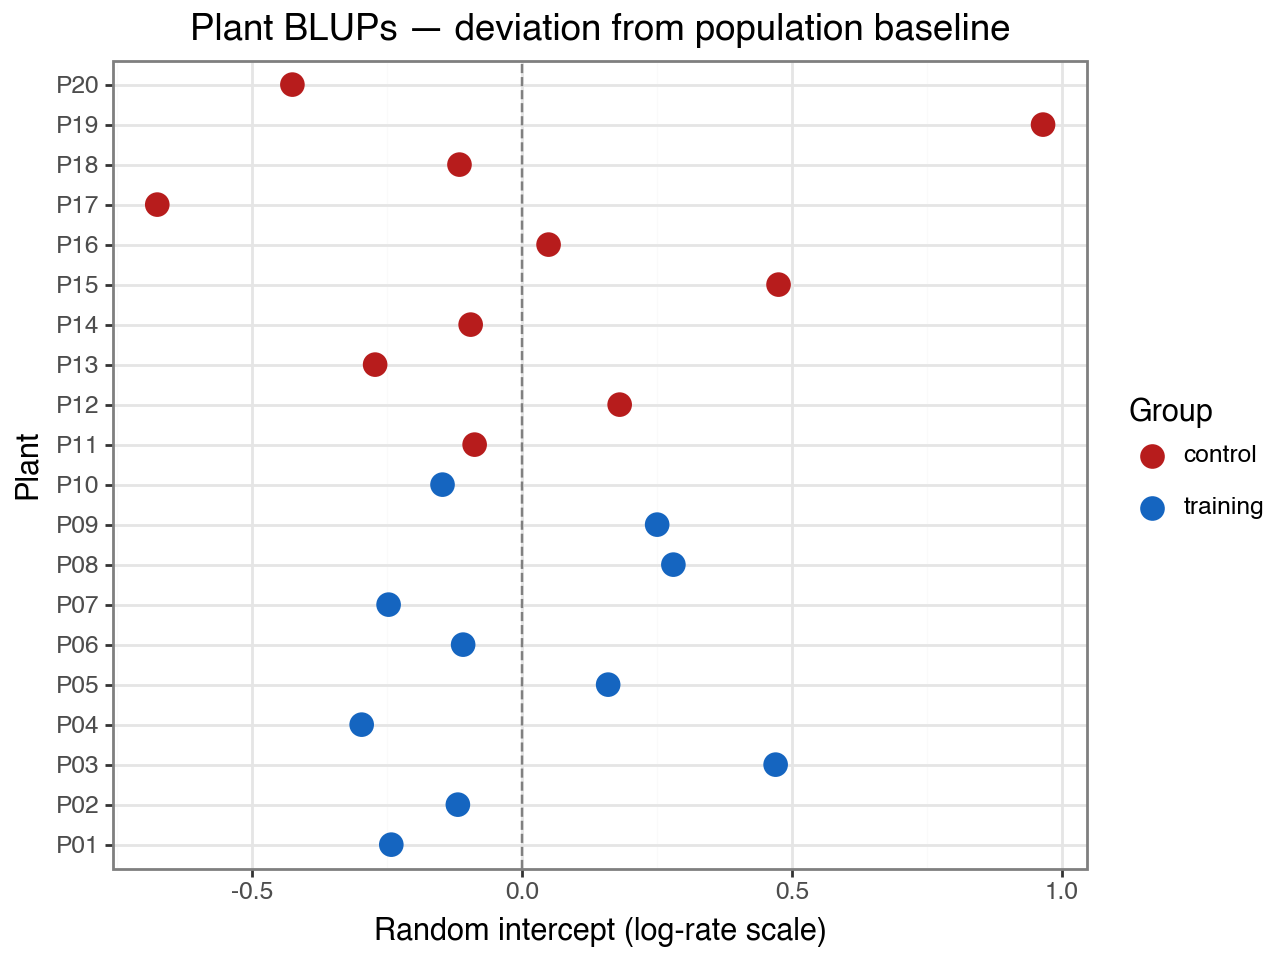

In [10]:
plant_blups = result.random_effects["plant"]

blup_df = pd.DataFrame({
    "plant": plant_blups.index,
    "blup": plant_blups.values,
})
blup_df["group"] = blup_df["plant"].map(
    lambda p: "training" if treatment[p] else "control"
)

(
    ggplot(blup_df, aes(x="plant", y="blup", color="group"))
    + geom_hline(yintercept=0, linetype="dashed", color="grey")
    + geom_point(size=4)
    + scale_color_manual(values={"training": "#1565C0", "control": "#B71C1C"})
    + coord_flip()
    + labs(
        x="Plant",
        y="Random intercept (log-rate scale)",
        title="Plant BLUPs — deviation from population baseline",
        color="Group",
    )
    + theme_bw()
)

## Deviance residuals

Deviance residuals are the GLMM analogue of standardised residuals in a linear
model. For a well-fitting Poisson GLMM, they should:

1. Show no systematic trend when plotted against fitted values.
2. Be approximately normally distributed (check with a Q–Q plot).
3. Have no values far beyond ±2–3 in magnitude.

In [11]:
# Compute deviance residuals from the family's dev_resids method
y = df["incidents"].values.astype(float)
mu = result.fittedvalues
wt = np.ones_like(y)

unit_dev = result.family.dev_resids(y, mu, wt)
dev_resid = np.sign(y - mu) * np.sqrt(np.abs(unit_dev))

resid_df = pd.DataFrame({
    "fitted": mu,
    "deviance_resid": dev_resid,
})

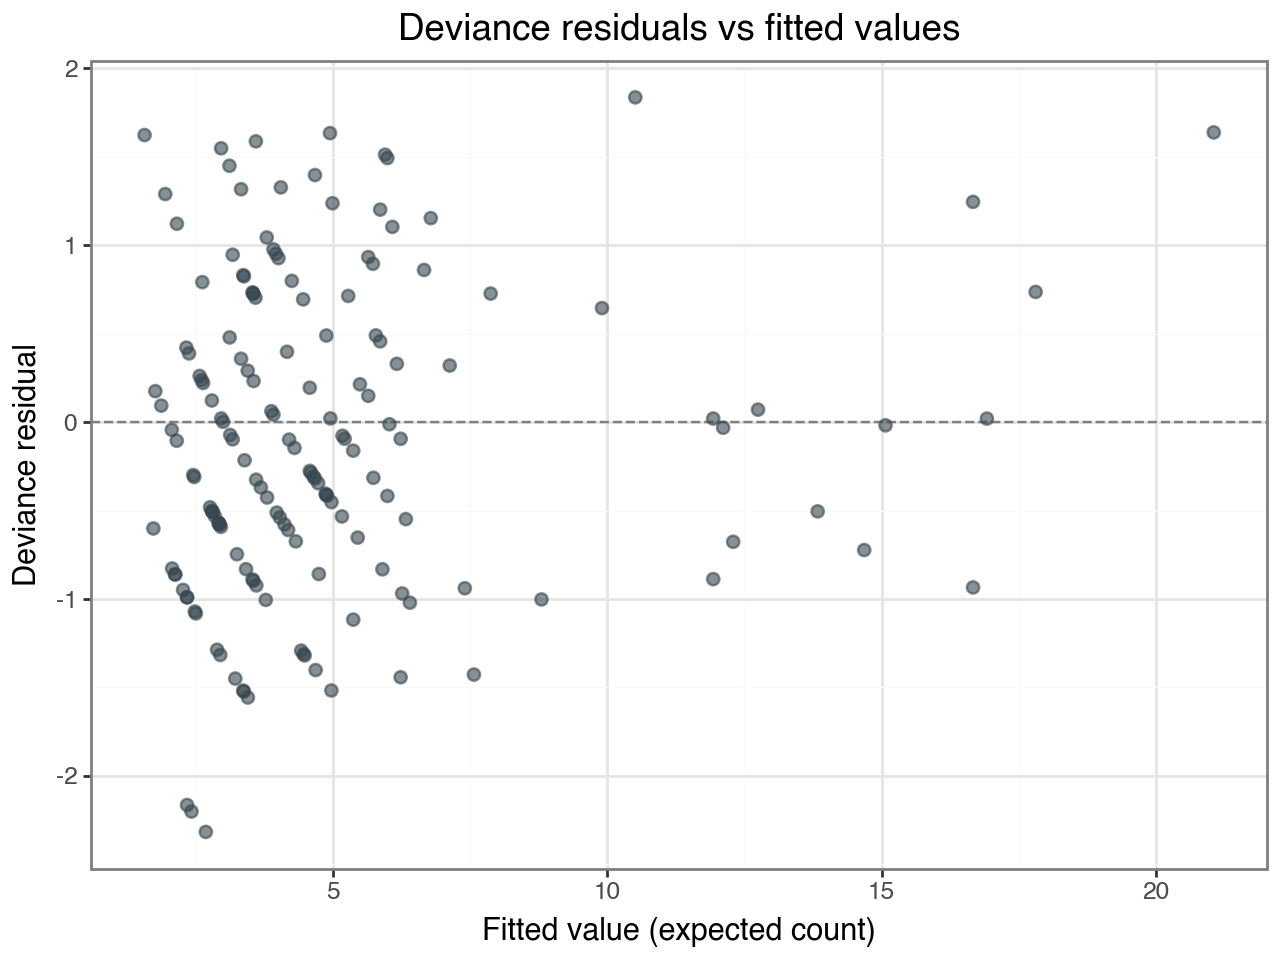

In [12]:
(
    ggplot(resid_df, aes(x="fitted", y="deviance_resid"))
    + geom_hline(yintercept=0, linetype="dashed", color="grey")
    + geom_point(alpha=0.6, size=2, color="#37474F")
    + labs(
        x="Fitted value (expected count)",
        y="Deviance residual",
        title="Deviance residuals vs fitted values",
    )
    + theme_bw()
)

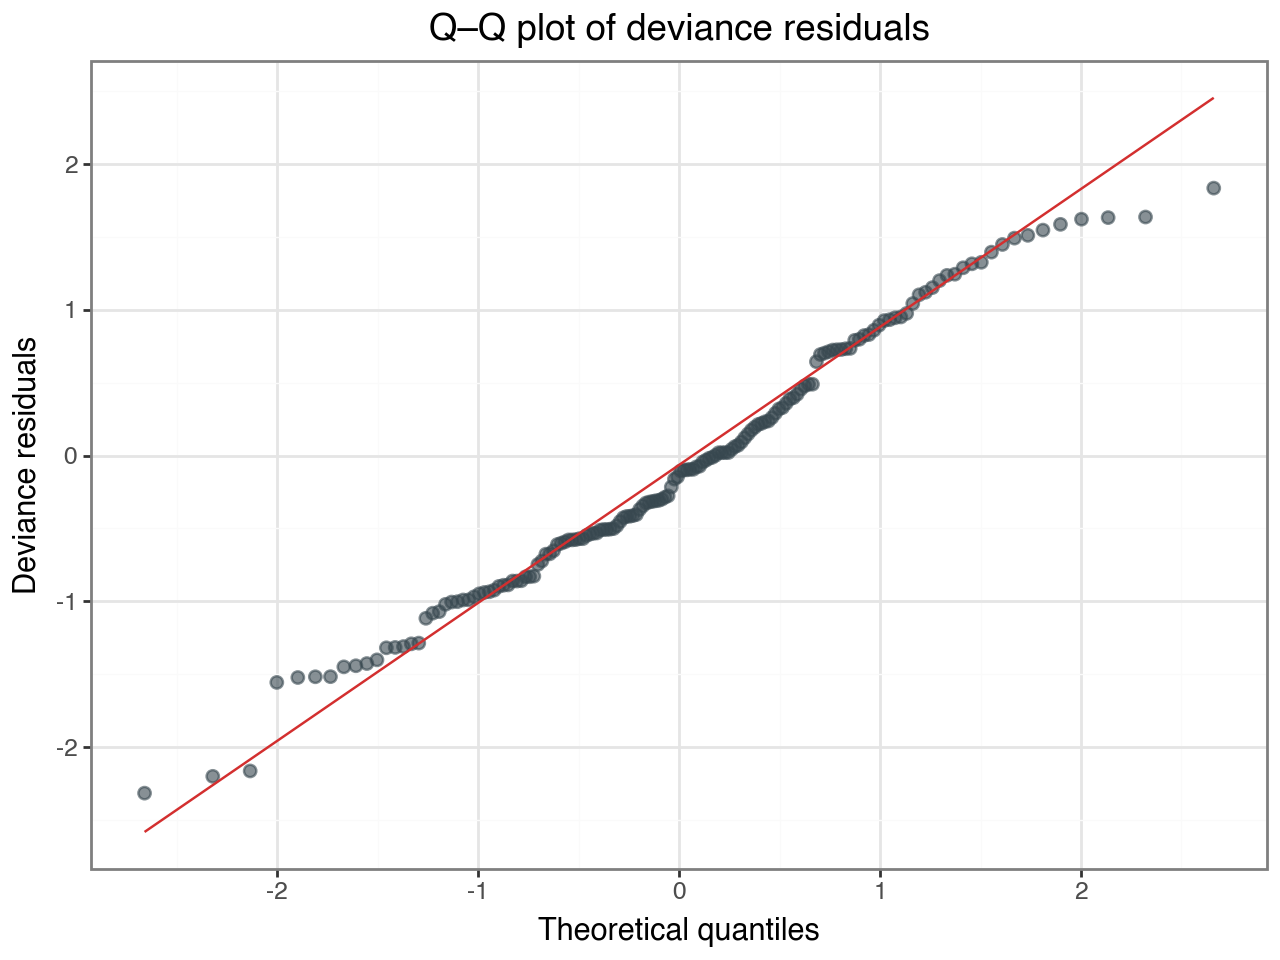

In [13]:
(
    ggplot(resid_df, aes(sample="deviance_resid"))
    + stat_qq(alpha=0.6, size=2, color="#37474F")
    + stat_qq_line(color="#D32F2F")
    + labs(
        x="Theoretical quantiles",
        y="Deviance residuals",
        title="Q–Q plot of deviance residuals",
    )
    + theme_bw()
)

If the residuals show no funnel pattern and the Q–Q plot is approximately linear,
the Poisson assumption is reasonable for these data.

## Checking for overdispersion

A Poisson model assumes that the conditional variance equals the conditional mean.
When variance exceeds the mean — *overdispersion* — standard errors are too narrow
and p-values too small. A quick diagnostic: the sum of squared Pearson residuals
divided by the residual degrees of freedom should be close to 1.0 for a
well-fitting Poisson model.

In [14]:
# Pearson residuals: (y - mu) / sqrt(mu)
pearson_resid = (y - mu) / np.sqrt(mu)
n_params = len(result.fe_params) + len(result.variance_components)
resid_df_stat = len(y) - n_params
overdisp_ratio = np.sum(pearson_resid ** 2) / resid_df_stat

print(f"Sum of squared Pearson residuals: {np.sum(pearson_resid**2):.2f}")
print(f"Residual df: {resid_df_stat}")
print(f"Overdispersion ratio: {overdisp_ratio:.3f}")
print()
if overdisp_ratio < 1.5:
    print("Ratio near 1 — no evidence of overdispersion. Poisson is adequate.")
else:
    print("Ratio > 1.5 — consider a negative binomial model.")

Sum of squared Pearson residuals: 118.66
Residual df: 156
Overdispersion ratio: 0.761

Ratio near 1 — no evidence of overdispersion. Poisson is adequate.


### Comparison with negative binomial

Even when the overdispersion ratio is near 1, it is good practice to fit a negative
binomial model and compare AIC. If the NB model does not improve fit, the simpler
Poisson model is preferred.

In [15]:
from interlace import NegativeBinomial2Family

result_nb = interlace.glmer(
    formula="incidents ~ training",
    data=df,
    family=NegativeBinomial2Family(theta=10.0),  # large theta ≈ Poisson
    groups=["plant", "month"],
    offset=np.log(df["employees"].values),
)

print(f"{'Model':<12}  {'AIC':>8}  {'BIC':>8}  {'training β':>12}  {'training SE':>12}")
print("-" * 60)
print(f"{'Poisson':<12}  {result.aic:>8.1f}  {result.bic:>8.1f}"
      f"  {result.fe_params['training']:>12.4f}  {result.fe_bse['training']:>12.4f}")
print(f"{'NB2':<12}  {result_nb.aic:>8.1f}  {result_nb.bic:>8.1f}"
      f"  {result_nb.fe_params['training']:>12.4f}  {result_nb.fe_bse['training']:>12.4f}")

Model              AIC       BIC    training β   training SE
------------------------------------------------------------
Poisson          715.5     727.8       -0.4170        0.1949
NB2              729.5     741.8       -0.4190        0.1935


Since the data were generated from a Poisson process (no overdispersion), the
Poisson model should have similar or lower AIC than the NB2 model, and the
treatment effect estimates should be nearly identical. In practice, always check
both — if the NB2 model has a substantially lower AIC, it indicates genuine
overdispersion that the Poisson model is missing.

## Laplace vs adaptive Gauss-Hermite quadrature (AGQ)

The default estimation method is the Laplace approximation (`nAGQ=1`). For models
with a single scalar random intercept, interlace also supports adaptive
Gauss-Hermite quadrature (`nAGQ > 1`), which provides a more accurate marginal
likelihood integral.

**Restriction:** `nAGQ > 1` requires exactly one grouping factor with a random
intercept only — no crossed effects or random slopes. This matches lme4's
restriction.

To demonstrate, we fit a simplified model with only the plant random intercept
(dropping the month random effect) and compare Laplace to AGQ with 25 quadrature
points.

In [16]:
# Simplified model: single grouping factor (plant only)
r_laplace = interlace.glmer(
    formula="incidents ~ training",
    data=df,
    family="poisson",
    groups="plant",
    offset=np.log(df["employees"].values),
    nAGQ=1,
)

r_agq = interlace.glmer(
    formula="incidents ~ training",
    data=df,
    family="poisson",
    groups="plant",
    offset=np.log(df["employees"].values),
    nAGQ=25,
)

print(f"{'':>16}  {'Laplace':>10}  {'AGQ(25)':>10}  {'Difference':>12}")
print("-" * 54)
print(f"{'Intercept':>16}  {r_laplace.fe_params['Intercept']:>10.4f}"
      f"  {r_agq.fe_params['Intercept']:>10.4f}"
      f"  {r_agq.fe_params['Intercept'] - r_laplace.fe_params['Intercept']:>12.5f}")
print(f"{'training':>16}  {r_laplace.fe_params['training']:>10.4f}"
      f"  {r_agq.fe_params['training']:>10.4f}"
      f"  {r_agq.fe_params['training'] - r_laplace.fe_params['training']:>12.5f}")
print(f"{'σ(plant)':>16}  {r_laplace.variance_components['plant']**0.5:>10.4f}"
      f"  {r_agq.variance_components['plant']**0.5:>10.4f}")
print(f"{'Log-lik':>16}  {r_laplace.llf:>10.2f}  {r_agq.llf:>10.2f}")
print(f"{'AIC':>16}  {r_laplace.aic:>10.1f}  {r_agq.aic:>10.1f}")

                     Laplace     AGQ(25)    Difference
------------------------------------------------------
       Intercept     -3.5428     -3.5429      -0.00007
        training     -0.4173     -0.4173       0.00005
        σ(plant)      0.3949      0.3954
         Log-lik     -360.74     -360.72
             AIC       727.5       727.4


With Poisson data and moderate cluster sizes (8 observations per plant), the
Laplace approximation and AGQ typically agree closely. Larger differences appear
with binary outcomes and very small cluster sizes (2–5 observations per group),
where the conditional distribution is far from Gaussian and the Laplace
approximation is less accurate.

For the full crossed model (plant × month), only `nAGQ=1` is available — use
the Laplace approximation.

## Prediction

Predictions can be made on the **response scale** (expected counts) or the
**link scale** (log rate). For new data with unknown group levels, set
`include_re=False` to get population-level predictions.

In [17]:
# Predict for a hypothetical plant with 200 employees.
# The offset (log employees) was passed separately at fit time, so we
# add it manually to the link-scale prediction.
newdata = pd.DataFrame({
    "training": [0, 1],
    "plant": ["NEW", "NEW"],
    "month": [1, 1],
})

# Population-level log-rate (no RE contribution for unknown plant)
log_rate = result.predict(newdata, type="link", include_re=False)

# Add the offset and convert to expected counts for 200 employees
n_employees = 200
expected_counts = np.exp(log_rate + np.log(n_employees))
rates_per_100 = expected_counts / n_employees * 100

pred_df = pd.DataFrame({
    "scenario": ["Control (200 employees)", "Training (200 employees)"],
    "expected_incidents": expected_counts.round(2),
    "rate_per_100": rates_per_100.round(3),
})
pred_df

,scenario,expected_incidents,rate_per_100
0,Control (200 employees),5.71,2.857
1,Training (200 employees),3.77,1.883


The population-level predictions reflect the fixed effects only. For a known
plant that appeared in the training data, `include_re=True` (the default) would
add that plant's BLUP to the linear predictor, giving a plant-specific prediction.

## Summary

| | |
|---|---|
| **Training effect** | ~34% reduction in incident rate (rate ratio ≈ 0.66), consistent with the true parameter (exp(−0.45) = 0.64) |
| **Plant variance** | SD ≈ 0.40 on log-rate scale — plants differ substantially in baseline safety |
| **Month variance** | SD ≈ 0.18 on log-rate scale — modest temporal fluctuation |
| **Overdispersion** | No evidence — Poisson model is adequate |
| **Laplace vs AGQ** | Negligible differences for these data; Laplace is sufficient |

### GLMM workflow checklist

1. **Choose the family** based on the outcome type (counts → Poisson, binary → binomial)
2. **Include an offset** if observations have different exposures (time, area, population)
3. **Fit the model** with `interlace.glmer()`
4. **Check deviance residuals** for patterns (trend, fanning, outliers)
5. **Test for overdispersion** by comparing Poisson to NB2 (AIC + Pearson ratio)
6. **Compare Laplace vs AGQ** for single-RE models with small clusters
7. **Interpret on the response scale** — exponentiate coefficients for rate ratios

### Reporting

```python
rr = np.exp(result.fe_params['training'])
print(f"Training rate ratio: {rr:.2f} "
      f"(95% CI: {np.exp(result.fe_params['training'] - 1.96*result.fe_bse['training']):.2f}"
      f"–{np.exp(result.fe_params['training'] + 1.96*result.fe_bse['training']):.2f})")
```

---

## Where to go next

- {doc}`glmm-quickstart` — API overview for binomial, Poisson, and NB GLMMs
- {doc}`api/glmer` — full `glmer()` parameter reference
- {doc}`api/glmm_families` — all available families (NB1, Beta, Gamma, ZIP, ZINB2, Hurdle, ZOIB)
- {doc}`case-study-politeness` — LMM case study with continuous outcomes
- {doc}`quickstart` — LMM quickstart for Gaussian data